In [1]:
from gensim.models import KeyedVectors
import pickle
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

In [2]:
kv = KeyedVectors.load(
    "./models--fse--word2vec-google-news-300/snapshots/528f381952a0b7d777bb4a611c4a43f588d48994/word2vec-google-news-300.model")

In [46]:
with open("/home/yvann/PycharmProjects/word2vec_lisa/general_audience_speeches_tokenized.pkl", "rb") as f:
    sentences_A = pickle.load(f)

with open("/home/yvann/PycharmProjects/word2vec_lisa/sentences_cbs.pkl", "rb") as f:
    sentences_B = pickle.load(f)

In [47]:
def normalize_token_for_kv(t: str, kv):
    # return the first form that exists
    for cand in (t, t.lower(), t.title(), t.upper()):
        if cand in kv:
            return cand
    return None


def build_counts(sentences):
    return Counter(t.lower() for toks in sentences for t in toks)


countsA = build_counts(sentences_A)
countsB = build_counts(sentences_B)
countsAll = countsA + countsB
N = sum(countsAll.values())


def doc_vector(toks, kv, countsAll, N, a=1e-3):
    # SIF-ish weight: a/(a + p(w))
    vecs = []
    wts = []
    for t in toks:
        key = normalize_token_for_kv(t, kv)
        if not key:
            continue
        p = countsAll[t.lower()] / N
        wt = a / (a + p)
        vecs.append(kv[key])
        wts.append(wt)

    if not vecs:
        return np.zeros(kv.vector_size, dtype=np.float32)

    vecs = np.vstack(vecs)
    wts = np.array(wts, dtype=np.float32)
    v = (vecs * wts[:, None]).sum(axis=0) / (wts.sum() + 1e-12)
    return v.astype(np.float32)


docA = np.vstack([doc_vector(toks, kv, countsAll, N) for toks in sentences_A])
docB = np.vstack([doc_vector(toks, kv, countsAll, N) for toks in sentences_B])


# cosine normalize
def l2norm(M):
    norms = np.linalg.norm(M, axis=1, keepdims=True) + 1e-12
    return M / norms


docA_n = l2norm(docA)
docB_n = l2norm(docB)

In [48]:
centA = docA_n.mean(axis=0);
centA /= (np.linalg.norm(centA) + 1e-12)
centB = docB_n.mean(axis=0);
centB /= (np.linalg.norm(centB) + 1e-12)

simA_to_B = docA_n @ centB
simB_to_A = docB_n @ centA

quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
qA = np.quantile(simA_to_B, quantiles)
qB = np.quantile(simB_to_A, quantiles)

qA, qB

(array([0.81922083, 0.85582936, 0.87580365, 0.91024518, 0.91624017]),
 array([0.42373882, 0.85202493, 0.8989011 , 0.93441248, 0.95795724]))

In [6]:
B_sample = docB_n[np.random.choice(len(docB_n), size=len(docA_n), replace=False)]

centB_sample = B_sample.mean(axis=0)
centB_sample /= np.linalg.norm(centB_sample)

simA_balanced = docA_n @ centB_sample
np.quantile(simA_balanced, [0.1, 0.25, 0.5, 0.75, 0.9])

array([0.8220976 , 0.85535824, 0.87665778, 0.90900254, 0.91549027])

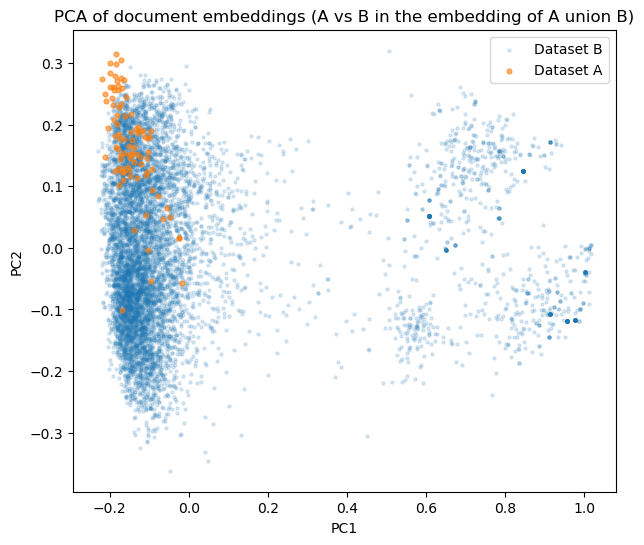

In [7]:
from sklearn.decomposition import PCA

X = np.vstack([docA_n, docB_n])
pca = PCA(n_components=2, random_state=0)
XY = pca.fit_transform(X)

XY_A = XY[:len(docA_n)]
XY_B = XY[len(docA_n):]
plt.figure(figsize=(7, 6))
plt.scatter(XY_B[:, 0], XY_B[:, 1], s=5, alpha=0.15, label="Dataset B")
plt.scatter(XY_A[:, 0], XY_A[:, 1], s=12, alpha=0.6, label="Dataset A")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA of document embeddings (A vs B in the embedding of A union B)")
plt.show()

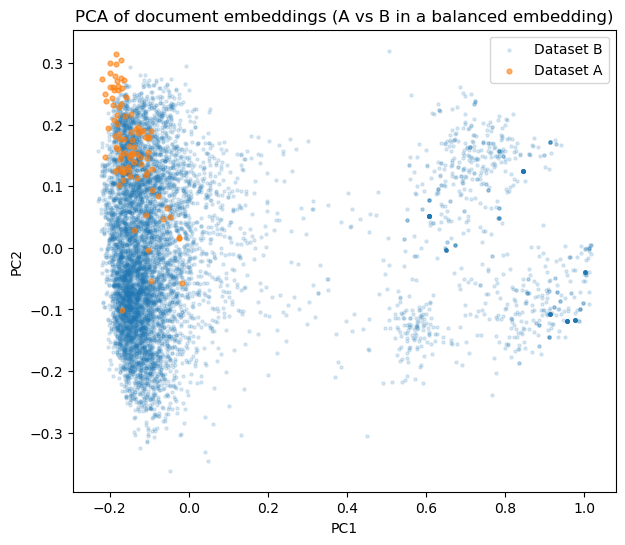

In [8]:
B_sample = docB_n[np.random.choice(len(docB_n), len(docA_n), replace=False)]
X_bal = np.vstack([docA_n, B_sample])

pca.fit_transform(X_bal)

XY_A = XY[:len(docA_n)]
XY_B = XY[len(docA_n):]
plt.figure(figsize=(7, 6))
plt.scatter(XY_B[:, 0], XY_B[:, 1], s=5, alpha=0.15, label="Dataset B")
plt.scatter(XY_A[:, 0], XY_A[:, 1], s=12, alpha=0.6, label="Dataset A")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA of document embeddings (A vs B in a balanced embedding)")
plt.show()



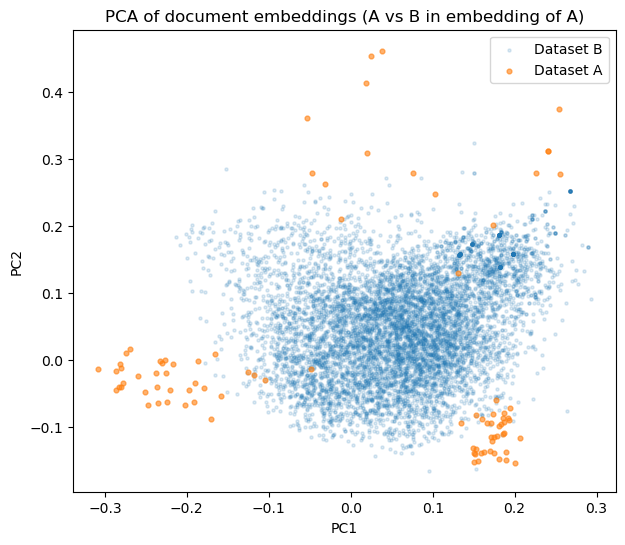

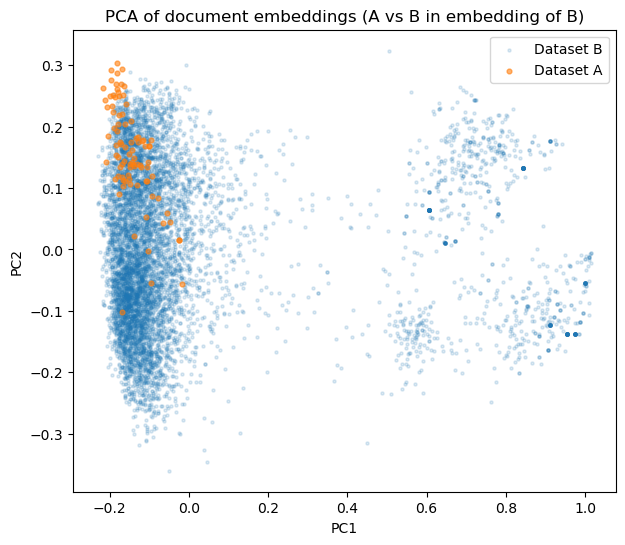

In [9]:
pca = PCA(n_components=2, random_state=0)
pca.fit(docA_n)

XY_A = pca.transform(docA_n)
XY_B = pca.transform(docB_n)

plt.figure(figsize=(7, 6))
plt.scatter(XY_B[:, 0], XY_B[:, 1], s=5, alpha=0.15, label="Dataset B")
plt.scatter(XY_A[:, 0], XY_A[:, 1], s=12, alpha=0.6, label="Dataset A")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA of document embeddings (A vs B in embedding of A)")
plt.show()

pca = PCA(n_components=2, random_state=0)
pca.fit(docB_n)

XY_A = pca.transform(docA_n)
XY_B = pca.transform(docB_n)

plt.figure(figsize=(7, 6))
plt.scatter(XY_B[:, 0], XY_B[:, 1], s=5, alpha=0.15, label="Dataset B")
plt.scatter(XY_A[:, 0], XY_A[:, 1], s=12, alpha=0.6, label="Dataset A")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA of document embeddings (A vs B in embedding of B)")  #not very interesting tbh
plt.show()





In [7]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=1, metric="cosine")
nn.fit(docB_n)

dist, idx = nn.kneighbors(docA_n)
# cosine distance = 1 - cosine similarity
sim_A_to_B = 1 - dist.ravel()

k = 20  # how many are selected
far_idx = np.argsort(sim_A_to_B)[:k]

res = dict()
for idx in far_idx:
    res[idx] = " ".join(sentences_A[idx])

In [41]:
res

{81: 'the fed has been assigned two goals for monetary policy maximum employment and stable prices we remain committed to supporting maximum employment bringing inflation sustainably to our goal and keeping longer term inflation expectations well anchored our success in delivering on these goals matters to all americans',
 79: 'the fed has been assigned two goals for monetary policy maximum employment and stable prices we remain committed to supporting maximum employment bringing inflation sustainably to our percent goal and keeping longer run inflation expectations well anchored our success in delivering on these goals matters to all americans',
 83: 'the fed has been assigned two goals for monetary policy maximum employment and stable prices we remain committed to bringing inflation back down to our percent goal and to keeping the longer term inflation expectations well anchored restoring price stability is essential to achieving maximum employment and stable prices over the longer r

In [6]:
### Loading the two other datasets and comparing alignment of A and B with them

with open("./public_news.pkl", "rb") as f:
    public_news_ds = pickle.load(f)

with open("./bloomberg_articles.pkl", "rb") as f:
    bloomberg_articles_ds = pickle.load(f)

#for idx, toks in enumerate(public_news_ds):
#    public_news_ds[idx] = [normalize_token_for_kv(tok, kv) for tok in toks]
#for idx, toks in enumerate(bloomberg_articles_ds):
#    bloomberg_articles_ds[idx] = [normalize_token_for_kv(tok, kv) for tok in toks]





In [40]:
def flatten(set_of_sentences, N=None, seed=None):
    """
    Flatten + subsample for reducing the computational overhead of the griddyversion
    """
    rng = random.Random(seed)
    return list(
        chain.from_iterable(
            rng.sample(x, min(len(x), N if N else len(x))) for x in set_of_sentences
        )
    )

In [8]:
# 🔧 Install if needed:
# !pip install faiss-cpu

import numpy as np
import faiss
import random
from itertools import chain


# ---------------------------
# 🔹 FAISS helpers
# ---------------------------

def build_faiss_index(vecs):
    dim = vecs.shape[1]
    index = faiss.IndexFlatIP(dim)  # cosine similarity if normalized
    index.add(vecs.astype(np.float32))
    return index


# ---------------------------
# 🔹 Main function
# ---------------------------

def symmetric_alignment_fast(X, Y, kv):
    """
    X, Y: lists of tokens
    kv: gensim KeyedVectors
    """

    # 1️⃣ Filter vocabulary (FIX: convert to list, not generator)
    vocab = kv.key_to_index
    X = [w for w in X if w in vocab]
    Y = [w for w in Y if w in vocab]

    if len(X) == 0 or len(Y) == 0:
        return 0.0

    # 2️⃣ Vectorized lookup (fast)
    X_vec = kv[X]
    Y_vec = kv[Y]

    # 3️⃣ Normalize once
    X_vec = l2norm(X_vec)
    Y_vec = l2norm(Y_vec)

    # 4️⃣ Build FAISS indices
    index_Y = build_faiss_index(Y_vec)
    index_X = build_faiss_index(X_vec)

    # 5️⃣ Nearest neighbor search
    sim_XY, _ = index_Y.search(X_vec.astype(np.float32), 1)
    sim_YX, _ = index_X.search(Y_vec.astype(np.float32), 1)

    # 6️⃣ Average similarities
    sim_XY = sim_XY.mean()
    sim_YX = sim_YX.mean()

    return float((sim_XY + sim_YX) / 2)



In [62]:
import pandas as pd
import numpy as np

# The datasets are very unbalanced, B contains ~= 100 sentences each of 300 tokens, while A contains
# 7400 sentences of length 2800~, therefore we subsample from A ~=100 sentences, each sentence being
# reduced to 300 tokens taken at random


selected_idx = np.random.choice(len(sentences_B), size=150, replace=False)  #subsample 100 sentences
sentences_B_subsampled = []
for idx in selected_idx:
    sentences_B_subsampled.append(sentences_B[idx])

flatten_A = flatten(sentences_A, None)
flatten_B = flatten(sentences_B_subsampled, 300)  #subsample only 10 tokens per sentence

# C'est très redondant ici, tu pourrais créer une fonction qui subsample des élts d'une liste
# générique, puis ensuite l'utiliser ici pour subsampler des phrases.

selected_idx = np.random.choice(len(public_news_ds), size=150, replace=False)
public_news_ds_subsampled = []
for idx in selected_idx:
    public_news_ds_subsampled.append(public_news_ds[idx])

selected_idx = np.random.choice(len(bloomberg_articles_ds), size=150, replace=False)
bloomberg_articles_ds_subsampled = []
for idx in selected_idx:
    bloomberg_articles_ds_subsampled.append(bloomberg_articles_ds[idx])

candidate = [
    ("public_news", flatten(public_news_ds_subsampled, 300)),
    ("bloomberg_news", flatten(bloomberg_articles_ds_subsampled, 300))
]

matrix = np.array([
    [symmetric_alignment_fast(flatten_A, ds, kv) for _, ds in candidate],
    [symmetric_alignment_fast(flatten_B, ds, kv) for _, ds in candidate]
])

matrix = np.round(matrix, 4)

# Create labeled DataFrame
df = pd.DataFrame(
    matrix,
    index=["A", "B"],  # rows
    columns=[name for name, _ in candidate]  # columns
)

print(df)
"""
Les résultats sont pas forcément très intéressants, en particulier en ce qui concerne
la compariason avec les public_news, compte-tenu qu'elles ne sont pas de nature financières
et qu'il est donc tout à fait prévisible que à la fois A et B soient moins alinés avec public_news
qu'avec bloomberg_news.
"""

   public_news  bloomberg_news
A       0.8584          0.8807
B       0.9122          0.9253


"\nLes résultats sont pas forcément très intéressants, en particulier en ce qui concerne\nla compariason avec les public_news, compte-tenu qu'elles ne sont pas de nature financières\net qu'il est donc tout à fait prévisible que à la fois A et B soient moins alinés avce public_news \nqu'avec bloomberg_news.\n"